# hand wirting data set 가여와서 숫자 학습시키고 예측까지 하기"

In [1]:
import tensorflow as tf    # tensorflow의 별명은 tf로 한다

print(tf.__version__)      # version 앞뒤로 두 개의 밑줄을 사용한다

2.19.0


In [2]:
# tensorflow와 tf.keras를 임포트
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#tf.keras.datasets.mnist.load_data()  # mnist 데이터셋을 로드한다
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()  # mnist 데이터셋을 로드한다

In [4]:
print(train_images.shape)
print(train_labels.shape)


print(train_labels[:10])

(60000, 28, 28)
(60000,)
[5 0 4 1 9 2 1 3 1 4]


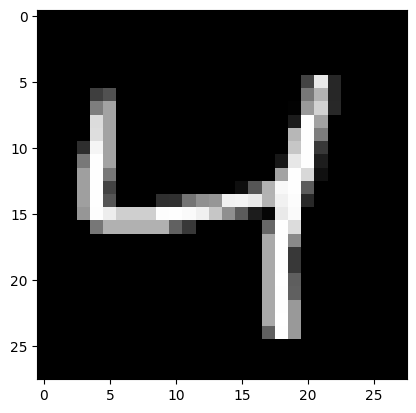

In [5]:
import matplotlib.pyplot as plt
plt.imshow(train_images[2], cmap='gray')

## 모델설계
* 입력 28*28
* 출력 10개
* 히든 1개, 촐력 1개 레이어
* 히든 레이어 512개의 퍼셉트론
* activation 선택이라는 것을 할 떄는 softmax를 채택한다.

In [6]:
input_layer=tf.keras.layers.Input(shape=(28*28,))  # 입력층
hidden_layer=tf.keras.layers.Dense(units=512, activation='relu') # 은닉층
output_layer=tf.keras.layers.Dense(units=10, activation='softmax') # 출력층
number=tf.keras.models.Sequential()


## 시퀀셜 선형 스택 모델 구축


In [7]:
number.add(input_layer)
number.add(hidden_layer)
number.add(output_layer)
number.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## SGD(0.9) 안에 있는건 Learnig Rate. 1보다 작아야 한다.

In [8]:
number.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Dataset 준비
import numpy as np
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

In [9]:
import numpy as np

train_images = train_images.reshape(60000, 28*28)
train_images = train_images /255.0 # 정규화
test_images = test_images.reshape(10000, 28*28)
test_images = test_images /255.0 # 정규화


# X = np.array(train_images)
# y = np.array(train_labels)


## 공부하자


In [13]:
number.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9040 - loss: 0.3355
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9766 - loss: 0.0787
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9841 - loss: 0.0497
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9902 - loss: 0.0308
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9927 - loss: 0.0239


## 값을 예측해봐

In [16]:
print(number.predict(test_images))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[8.7128316e-10 8.6020448e-11 2.6671336e-07 ... 9.9999934e-01
  2.9126732e-09 5.0851025e-08]
 [1.2354638e-09 1.3154084e-06 9.9996227e-01 ... 2.2619784e-13
  4.4375713e-07 5.0237429e-13]
 [1.1005803e-07 9.9946105e-01 4.6943496e-06 ... 7.6661658e-05
  4.1461087e-04 6.8338511e-07]
 ...
 [8.6919469e-13 1.6523466e-10 9.3285588e-11 ... 5.1139112e-05
  5.1916827e-06 1.0487958e-03]
 [6.6738997e-12 4.4613538e-16 5.3934039e-15 ... 2.1150171e-12
  2.5541294e-08 1.1000257e-14]
 [1.2121489e-10 3.7395177e-18 3.0905788e-12 ... 1.1953499e-17
  2.0885633e-12 6.0082220e-15]]


(10000, 784)
(10000,)
[7 2 1 0 4 1 4 9 5 9]


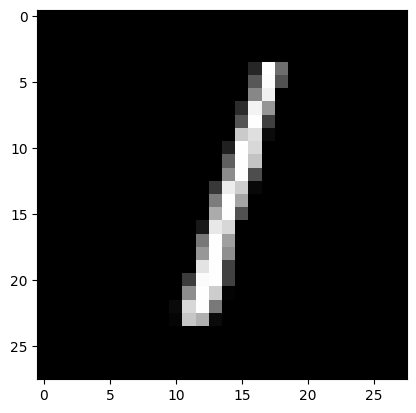

In [17]:
print(test_images.shape)
print(test_labels.shape)


print(test_labels[:10])

plt.imshow(test_images[2].reshape(28, 28), cmap='gray')